In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
dataset=pd.read_csv("Train.csv")

In [7]:
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
dataset.shape

(614, 13)

In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [10]:
dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [11]:
dataset.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

# Checking for outliers and skewness in Applicant Income

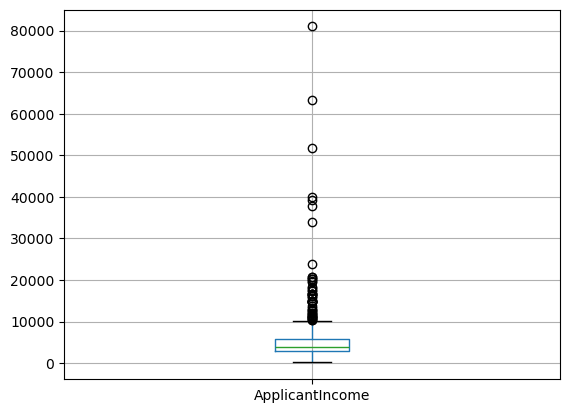

In [12]:
dataset.boxplot(column='ApplicantIncome')
plt.show()

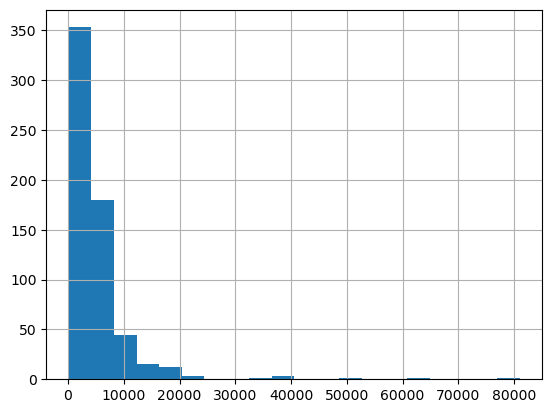

In [13]:
dataset['ApplicantIncome'].hist(bins=20)
plt.show()

# Checking for outliers and skewness in Co-Applicant Income

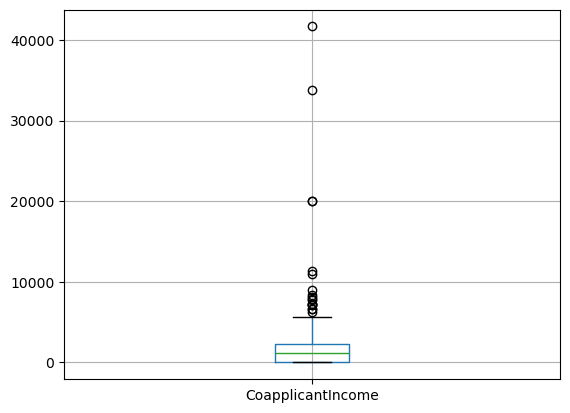

In [14]:
dataset.boxplot(column='CoapplicantIncome')
plt.show()

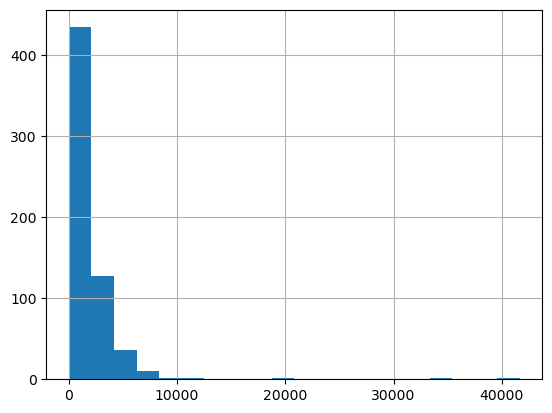

In [15]:
dataset['CoapplicantIncome'].hist(bins=20)
plt.show()

# Checking for outliers and skewness in Loan Amount

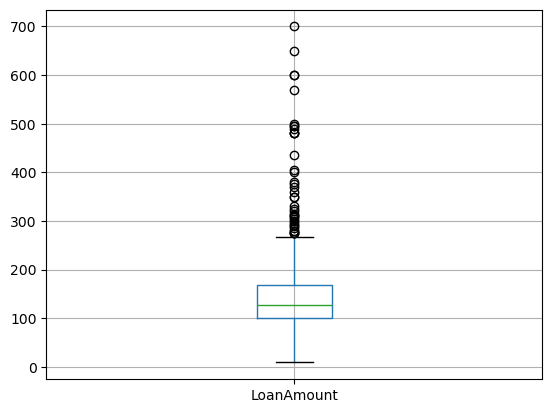

In [16]:
dataset.boxplot(column='LoanAmount')
plt.show()

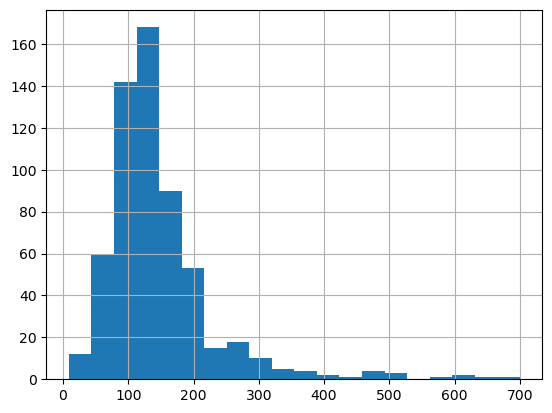

In [17]:
dataset['LoanAmount'].hist(bins=20)
plt.show()

# Normalizing the Distribution/reducing the skewness and feature engineering

In [18]:
dataset['TotalIncome']=dataset['ApplicantIncome']+dataset['CoapplicantIncome']
dataset['TotalIncome_Log']=np.log(dataset['TotalIncome'])

In [19]:
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,TotalIncome_Log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,5849.0,8.674026
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,8.714568
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,8.006368
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,8.505323
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,8.699515


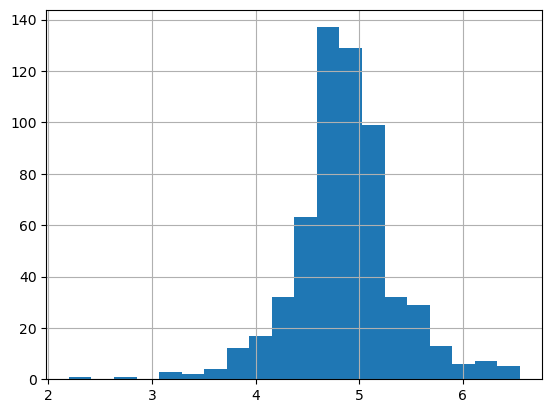

In [20]:
dataset['LoanAmount_Log']=np.log(dataset['LoanAmount'])
dataset['LoanAmount_Log'].hist(bins=20)
plt.show()

# Checking and handling the Missing Values

In [21]:
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
TotalIncome           0
TotalIncome_Log       0
LoanAmount_Log       22
dtype: int64

In [22]:
dataset.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'TotalIncome', 'TotalIncome_Log', 'LoanAmount_Log'],
      dtype='object')

In [23]:
dataset['Gender'].fillna(dataset['Gender'].mode()[0],inplace=True)
dataset['Married'].fillna(dataset['Married'].mode()[0],inplace=True)
dataset['Dependents'].fillna(dataset['Dependents'].mode()[0],inplace=True)
dataset['Self_Employed'].fillna(dataset['Self_Employed'].mode()[0],inplace=True)
dataset.LoanAmount=dataset.LoanAmount.fillna(dataset.LoanAmount.mean())
dataset.LoanAmount_Log=dataset.LoanAmount_Log.fillna(dataset.LoanAmount.mean())
dataset['Loan_Amount_Term'].fillna(dataset['Loan_Amount_Term'].mode()[0],inplace=True)
dataset['Credit_History'].fillna(dataset['Credit_History'].mode()[0],inplace=True)

In [24]:
dataset.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
TotalIncome          0
TotalIncome_Log      0
LoanAmount_Log       0
dtype: int64

In [25]:
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,TotalIncome_Log,LoanAmount_Log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0,8.674026,146.412162
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,6091.0,8.714568,4.852030
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0,8.006368,4.189655
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4941.0,8.505323,4.787492
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0,8.699515,4.948760


# What is the distribution of loan approval status

# 2. How does credit history influence loan approval?

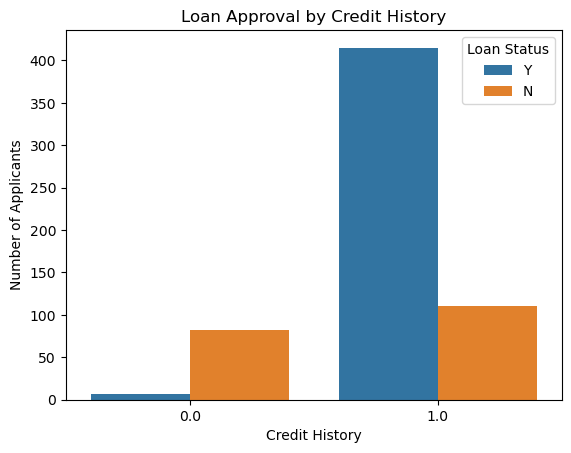

In [26]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=dataset)
plt.title('Loan Approval by Credit History')
plt.xlabel('Credit History')
plt.ylabel('Number of Applicants')
plt.legend(title='Loan Status')
plt.show()


This plot shows that applicants with a positive credit history (Credit_History=1) have a significantly higher number of loan approvals compared to those with a negative credit history (Credit_History=0). This suggests that credit history is a strong predictor of loan approval.

# 2. How does Applicant Income differ between approved and rejected loans?

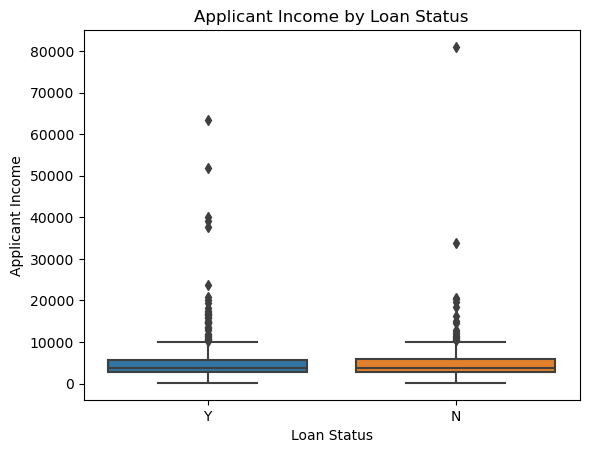

In [29]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=dataset)
plt.title('Applicant Income by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Applicant Income')
plt.show()

# 3. How does Loan Amount (loan burden) vary between approved and rejected loans?

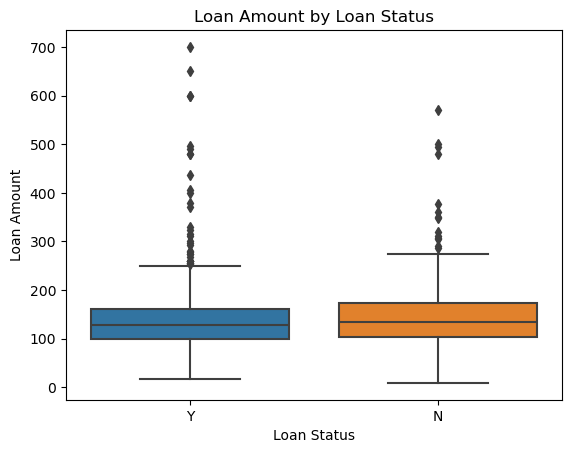

In [30]:
sns.boxplot(x='Loan_Status', y='LoanAmount', data=dataset)
plt.title('Loan Amount by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')
plt.show()

Applicants with lower loan amounts tend to have higher approval rates, indicating that lower loan burden positively impacts the likelihood of loan approval.

# 4. Does Marital Status affect Loan Approval?

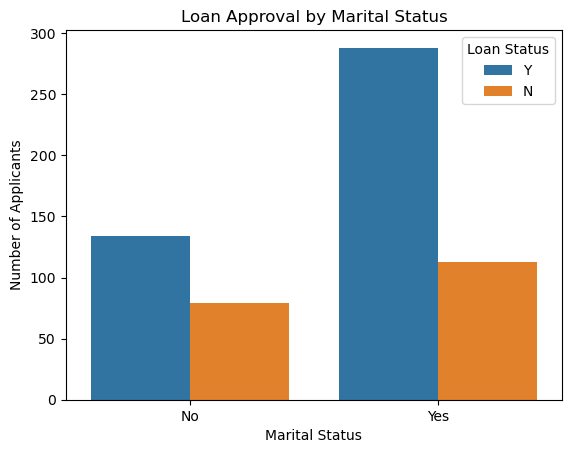

In [32]:
sns.countplot(x='Married', hue='Loan_Status', data=dataset)
plt.title('Loan Approval by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Applicants')
plt.legend(title='Loan Status')
plt.show()

Loan approval rates appear slightly higher for married applicants compared to single ones, suggesting marital status has a modest influence on loan decisions.

# 5. What is the impact of Number of Dependents on Loan Approval?

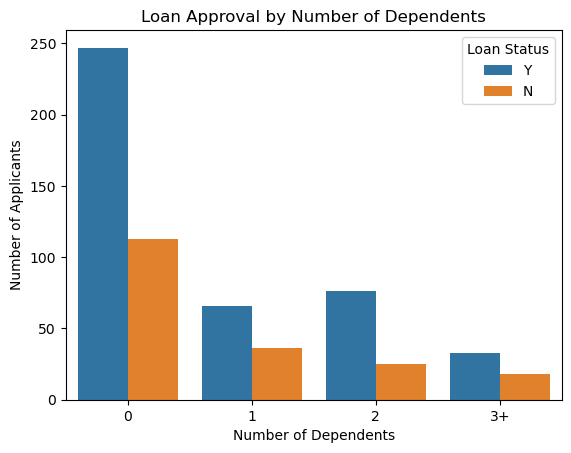

In [33]:
sns.countplot(x='Dependents', hue='Loan_Status', data=dataset)
plt.title('Loan Approval by Number of Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Number of Applicants')
plt.legend(title='Loan Status')
plt.show()

Loan approval rates show some variation with the number of dependents, with fewer dependents generally corresponding to higher approval chances.

# 6. How does Property Area relate to Loan Approval?

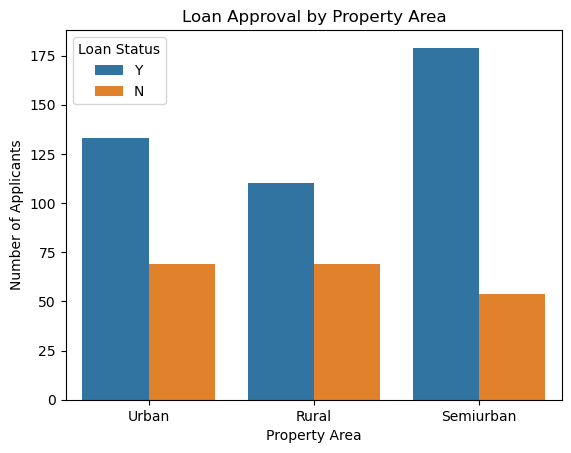

In [34]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=dataset)
plt.title('Loan Approval by Property Area')
plt.xlabel('Property Area')
plt.ylabel('Number of Applicants')
plt.legend(title='Loan Status')
plt.show()

Applicants from semi-urban areas tend to have higher approval rates compared to rural or urban areas, indicating location influences loan decisions.

# 7. Does Education Level influence Loan Approval?

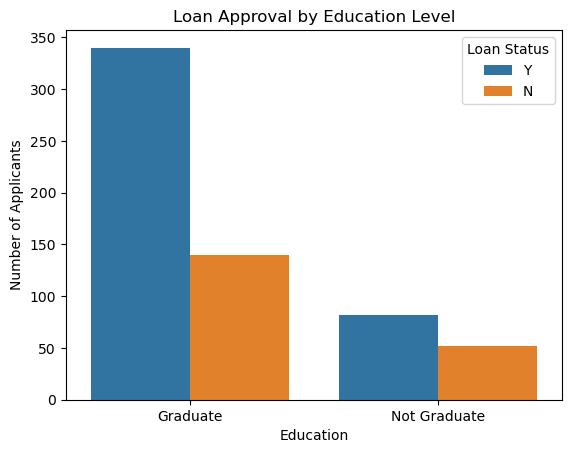

In [35]:
sns.countplot(x='Education', hue='Loan_Status', data=dataset)
plt.title('Loan Approval by Education Level')
plt.xlabel('Education')
plt.ylabel('Number of Applicants')
plt.legend(title='Loan Status')
plt.show()

Graduates appear to have a slightly better chance of loan approval than non-graduates, suggesting education level plays a smaller but positive role.

# 9. Interaction: How does Applicant Income and Loan Approval vary by Credit History?

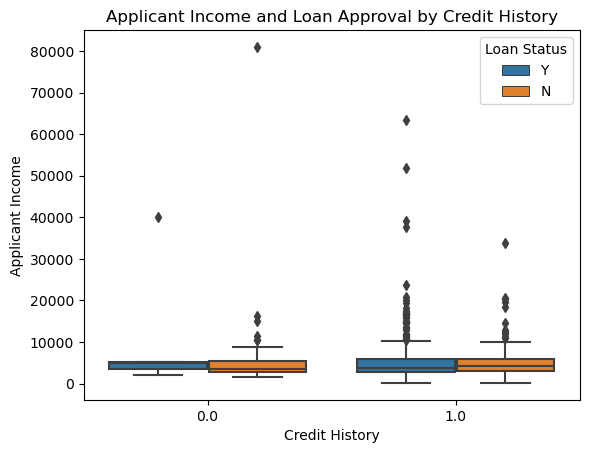

In [38]:
sns.boxplot(x='Credit_History', y='ApplicantIncome', hue='Loan_Status', data=dataset)
plt.title('Applicant Income and Loan Approval by Credit History')
plt.xlabel('Credit History')
plt.ylabel('Applicant Income')
plt.legend(title='Loan Status')
plt.show()

For applicants with a positive credit history, those with higher income have higher approval rates. Conversely, applicants with poor credit history tend to have lower incomes and lower approval rates, confirming credit history and income together strongly impact approval chances.

Key insights

Credit History stands out as the most significant predictor of loan approval, underscoring the importance of past financial behavior in lending decisions.

Income Stability and Loan Burden: Applicants with steady incomes and lower existing loan burdens have a higher likelihood of loan approval, indicating lenders’ preference for financially reliable candidates.

Demographic Factors: Marital status and number of dependents have a modest but measurable effect on approval outcomes, suggesting some demographic considerations in risk assessment.

Property Area: Applicants from semi-urban areas exhibit better approval rates compared to rural or urban counterparts, possibly reflecting regional economic factors.

Education and Employment: While these factors influence loan approval decisions, their impact is relatively smaller compared to credit history and income stability.

Predictions Using ML Concepts